# V3 HMM Analysis and Inference

This notebook analyzes the converged V3 two-emission NH-HMM selected in the model-selection workflow.

Selected model: `single_period, J=3`

## Table of Contents

1. [Load V3 Model and Dataset](#1-load-v3-model-and-dataset)
2. [Posterior State Assignment](#2-posterior-state-assignment)
3. [Summary Statistics](#3-summary-statistics)
4. [Publication-Style Estimation Results](#4-publication-style-estimation-results)
5. [Baseline Transition Probabilities](#5-baseline-transition-probabilities)
6. [State-Dependent Time Trends](#6-state-dependent-time-trends)
7. [Output Files](#7-output-files)


---
<a id="1-load-v3-model-and-dataset"></a>
## 1. Load V3 Model and Dataset


In [1]:
from __future__ import annotations

import pickle
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import logsumexp, softmax
from scipy.stats import linregress, norm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140


@dataclass
class Params:
    logit_pi: np.ndarray
    alpha: np.ndarray
    beta: np.ndarray
    mu: np.ndarray
    W: np.ndarray
    log_sigma: np.ndarray


setattr(sys.modules["__main__"], "Params", Params)


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "Datasets").exists() and (candidate / "HMM Estimation").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
HMM_DIR = PROJECT_ROOT / "HMM Estimation"
ARTIFACT_DIR = HMM_DIR / "Artefacts"
ANALYSIS_DIR = ARTIFACT_DIR / "Analysis_v3"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ARTIFACT_PATH = ARTIFACT_DIR / "best_model_artifacts_v3_2emissions.pkl"
COMPARISON_PATH = ARTIFACT_DIR / "model_selection_v3_single_vs_3period.csv"

with MODEL_ARTIFACT_PATH.open("rb") as f:
    artifacts = pickle.load(f)

best_model = artifacts["best_model"]
best_J = int(artifacts["best_J"])
best_spec = artifacts["best_spec"]
emission_cols = list(artifacts["emission_cols"])
transition_cols = list(artifacts["transition_cols"])
control_cols = list(artifacts["control_cols"])
manager_heterogeneity_xi = float(artifacts.get("manager_heterogeneity_xi", 0.6447))
y_scaler = artifacts["y_scaler"]
x_scaler = artifacts["x_scaler"]
z_scaler = artifacts.get("z_scaler")

DATA_PATH = Path(artifacts.get("dataset_path", ""))
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "Datasets" / "Triadic_Delegation_Analysis_Dataset_v3.xlsx"

panel = pd.read_excel(DATA_PATH, sheet_name="panel_manager_period")
model_comparison = pd.read_csv(COMPARISON_PATH)

VARIABLE_LABELS = artifacts.get("variable_labels") or {}
VARIABLE_LABELS.update({
    "ai_authority_share": "AI Authority Share",
    "escalation_share": "Escalation Share",
    "decision_latency": "Decision Latency",
    "demand_volatility": "Demand Volatility",
    "forecast_accuracy": "Forecast Accuracy",
    "performance_pressure": "Performance Pressure",
    "recent_negative_shock": "Recent Negative Shock",
    "supply_disruptions": "Supply Disruptions",
    "target_difficulty": "Target Difficulty",
    "task_complexity": "Task Complexity",
    "team_t_minus_1_vs_team_t": "Team (t-1) vs Team (t)",
    "team_vs_peer_average": "Team vs Peer Average",
    "target_attainment": "Target Attainment",
    "composite_kpi_score": "Composite KPI Score",
    "kpi_target": "KPI Target",
})

print(f"Loaded model artifact: {MODEL_ARTIFACT_PATH}")
print(f"Loaded dataset: {DATA_PATH}")
print(f"Selected model: spec={best_spec}, J={best_J}")
print(f"Emissions: {emission_cols}")
print(f"Transition variables: {transition_cols}")
print(f"Emission controls: {control_cols}")
print(f"Panel rows: {len(panel):,}")


Loaded model artifact: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\best_model_artifacts_v3_2emissions.pkl
Loaded dataset: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\Datasets\Triadic_Delegation_Analysis_Dataset_v3.xlsx
Selected model: spec=single_period, J=3
Emissions: ['ai_authority_share', 'escalation_share']
Transition variables: ['team_t_minus_1_vs_team_t', 'team_vs_peer_average', 'target_attainment']
Emission controls: ['decision_latency', 'demand_volatility', 'forecast_accuracy', 'performance_pressure', 'recent_negative_shock', 'supply_disruptions', 'target_difficulty', 'task_complexity']
Panel rows: 22,750


In [2]:
# Shared plotting/table helpers

def display_label(col: str) -> str:
    return VARIABLE_LABELS.get(col, col.replace("_", " ").title())


def stars_from_p(pval: float) -> str:
    if not np.isfinite(pval):
        return ""
    if pval < 0.01:
        return "***"
    if pval < 0.05:
        return "**"
    if pval < 0.10:
        return "*"
    return ""


def fmt_coef(value: float, pval: float | None = None, digits: int = 4) -> str:
    suffix = "" if pval is None else stars_from_p(float(pval))
    return f"{value:.{digits}f}{suffix}"


def fmt_pct(value: float, digits: int = 2) -> str:
    return f"{100.0 * value:.{digits}f}%"


def save_table_image(df: pd.DataFrame, title: str, path: Path, footnote: str | None = None, section_col: str | None = None) -> None:
    render_df = df.copy()
    section_flags = None
    if section_col and section_col in render_df.columns:
        section_flags = render_df[section_col].astype(bool).to_numpy()
        render_df = render_df.drop(columns=[section_col])

    n_rows, n_cols = render_df.shape
    fig_h = max(3.0, 0.34 * (n_rows + 3))
    fig_w = max(12.0, 2.9 * n_cols)
    if n_cols >= 5:
        fig_w = max(fig_w, 16.0)

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")
    title_ax = fig.add_axes([0.0, 0.925, 1.0, 0.06])
    title_ax.set_facecolor("black")
    title_ax.set_xticks([])
    title_ax.set_yticks([])
    for spine in title_ax.spines.values():
        spine.set_visible(False)
    title_ax.text(0.012, 0.5, title, va="center", ha="left", color="white", weight="bold", fontsize=15)

    ax = fig.add_axes([0.012, 0.085 if footnote else 0.035, 0.976, 0.82 if footnote else 0.87])
    ax.axis("off")

    if n_cols == 5:
        col_widths = [0.42, 0.145, 0.145, 0.145, 0.145]
    elif n_cols == 6:
        col_widths = [0.28, 0.18, 0.12, 0.14, 0.14, 0.14]
    else:
        first_width = 0.28 if n_cols > 2 else 0.5
        other_width = (1.0 - first_width) / max(n_cols - 1, 1)
        col_widths = [first_width] + [other_width] * (n_cols - 1)

    table = ax.table(
        cellText=render_df.values,
        colLabels=render_df.columns,
        loc="upper left",
        cellLoc="center",
        colLoc="center",
        colWidths=col_widths[:n_cols],
        bbox=[0.0, 0.0, 1.0, 1.0],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.0 if n_rows > 28 else 9.5)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor("#111111")
            cell.get_text().set_color("white")
            cell.get_text().set_weight("bold")
        elif section_flags is not None and section_flags[row - 1]:
            cell.set_facecolor("#d9d9d9")
            cell.get_text().set_weight("bold")
        else:
            cell.set_facecolor("white")
        if col == 0:
            cell.get_text().set_ha("left")
            cell.get_text().set_wrap(True)

    if footnote:
        fig.text(0.012, 0.025, footnote, fontsize=9, ha="left", va="bottom")
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)

def add_caption_bar(fig, caption: str) -> None:
    fig.subplots_adjust(bottom=0.18)
    fig.text(0.02, 0.035, caption, color="white", fontsize=13, weight="bold",
             bbox={"facecolor": "black", "edgecolor": "black", "pad": 7})


---
<a id="2-posterior-state-assignment"></a>
## 2. Posterior State Assignment


In [3]:
def log_softmax_np(z: np.ndarray, axis: int = -1) -> np.ndarray:
    return z - logsumexp(z, axis=axis, keepdims=True)


def forward_backward(p: Params, Y: np.ndarray, X: np.ndarray, Z: np.ndarray) -> tuple[float, np.ndarray]:
    T = Y.shape[0]
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum("jdk,tk->tjd", p.W, Z)
    resid = Y[:, None, :] - means
    sigma2 = np.exp(2.0 * p.log_sigma)
    log_norm = np.sum(np.log(2.0 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] + np.sum(resid**2 / sigma2[None, :, :], axis=2))
    logits = p.alpha[None, :, :] + np.einsum("ijp,tp->tij", p.beta, X)
    logQ = log_softmax_np(logits, axis=2)
    log_pi = log_softmax_np(p.logit_pi, axis=0)

    log_alpha = np.empty((T, J))
    log_alpha[0] = log_pi + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(log_alpha[t - 1, :, None] + logQ[t], axis=0)

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(logQ[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :], axis=1)

    ll = float(logsumexp(log_alpha[-1]))
    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma


def ensure_transition_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rebuild derived transition columns when the selected artifact uses them."""
    df = df.sort_values(["manager_id", "period_id"]).copy()
    g = df.groupby("manager_id", group_keys=False)
    if "team_prev3_avg_vs_team_t" not in df.columns and "composite_kpi_score" in df.columns:
        prev3_kpi = g["composite_kpi_score"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
        df["team_prev3_avg_vs_team_t"] = (df["composite_kpi_score"] - prev3_kpi).fillna(0.0)
    if "team_vs_peer_average_3period" not in df.columns and "team_vs_peer_average" in df.columns:
        df["team_vs_peer_average_3period"] = g["team_vs_peer_average"].transform(lambda s: s.rolling(3, min_periods=1).mean())
    if "target_attainment_3period" not in df.columns and "target_attainment" in df.columns:
        df["target_attainment_3period"] = g["target_attainment"].transform(lambda s: s.rolling(3, min_periods=1).mean())
    return df


panel = ensure_transition_columns(panel)


required_cols = ["manager_id", "period_id", *emission_cols, *transition_cols, *control_cols]
panel_model = panel.dropna(subset=required_cols).sort_values(["manager_id", "period_id"]).copy()

Y_list, X_list, Z_list, id_list, period_list = [], [], [], [], []
for manager_id, grp in panel_model.groupby("manager_id", sort=True):
    grp = grp.sort_values("period_id")
    Y_list.append(y_scaler.transform(grp[emission_cols].to_numpy(float)))
    X_list.append(x_scaler.transform(grp[transition_cols].to_numpy(float)))
    if control_cols:
        Z_list.append(z_scaler.transform(grp[control_cols].to_numpy(float)))
    else:
        Z_list.append(np.zeros((len(grp), 0), dtype=float))
    id_list.append(manager_id)
    period_list.append(grp["period_id"].to_numpy(int))

mu_orig = y_scaler.inverse_transform(best_model.mu)
sigma_orig = np.exp(best_model.log_sigma) * y_scaler.scale_[None, :]
authority_idx = emission_cols.index("ai_authority_share")
state_order_0idx = np.argsort(mu_orig[:, authority_idx]).tolist()
state_order_1idx = [idx + 1 for idx in state_order_0idx]

if best_J == 4:
    ordered_state_labels = ["Aversion", "Neutral-Low", "Neutral-High", "Appreciation"]
elif best_J == 3:
    ordered_state_labels = ["Aversion", "Neutral", "Appreciation"]
elif best_J == 2:
    ordered_state_labels = ["Aversion", "Appreciation"]
else:
    ordered_state_labels = [f"State {i+1}" for i in range(best_J)]

label_map = {raw_state: ordered_state_labels[pos] for pos, raw_state in enumerate(state_order_1idx)}
state_columns = [f"State {label}" for label in ordered_state_labels]

posterior_rows = []
ll_values = []
for manager_id, periods, Y_i, X_i, Z_i in zip(id_list, period_list, Y_list, X_list, Z_list):
    ll_i, log_gamma_i = forward_backward(best_model, Y_i, X_i, Z_i)
    ll_values.append(ll_i)
    gamma_i = np.exp(log_gamma_i)
    ml_state = np.argmax(gamma_i, axis=1) + 1
    for row_idx, period_id in enumerate(periods):
        rec = {
            "manager_id": manager_id,
            "period_id": int(period_id),
            "most_likely_state": int(ml_state[row_idx]),
            "state_label": label_map[int(ml_state[row_idx])],
            "state_order": ordered_state_labels.index(label_map[int(ml_state[row_idx])]),
        }
        for state_idx in range(best_J):
            rec[f"gamma_state_{state_idx + 1}"] = float(gamma_i[row_idx, state_idx])
        posterior_rows.append(rec)

posteriors = pd.DataFrame(posterior_rows)
state_order_1idx = (
    panel_model[["manager_id", "period_id", "ai_authority_share"]]
    .merge(posteriors[["manager_id", "period_id", "most_likely_state"]], on=["manager_id", "period_id"], how="left")
    .groupby("most_likely_state")["ai_authority_share"]
    .mean()
    .sort_values()
    .index.astype(int)
    .tolist()
)
state_order_0idx = [idx - 1 for idx in state_order_1idx]
if best_J == 4:
    ordered_state_labels = ["Aversion", "Neutral-Low", "Neutral-High", "Appreciation"]
elif best_J == 3:
    ordered_state_labels = ["Aversion", "Neutral", "Appreciation"]
elif best_J == 2:
    ordered_state_labels = ["Aversion", "Appreciation"]
else:
    ordered_state_labels = [f"State {i+1}" for i in range(best_J)]
label_map = {raw_state: ordered_state_labels[pos] for pos, raw_state in enumerate(state_order_1idx)}
state_columns = [f"State {label}" for label in ordered_state_labels]
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)
posteriors["state_order"] = posteriors["state_label"].map({label: pos for pos, label in enumerate(ordered_state_labels)})
initial_state = (
    posteriors.sort_values(["manager_id", "period_id"])
    .groupby("manager_id", as_index=False)
    .first()[["manager_id", "state_label", "state_order"]]
    .rename(columns={
        "state_label": "baseline_state_label",
        "state_order": "baseline_state_order",
    })
)
panel_state = panel_model.merge(posteriors, on=["manager_id", "period_id"], how="left")
panel_state = panel_state.merge(initial_state, on="manager_id", how="left")
posterior_path = ANALYSIS_DIR / "posterior_state_assignments_v3.csv"
posteriors.to_csv(posterior_path, index=False)

print(f"Computed posterior states for {len(posteriors):,} manager-period observations")
print(f"Forward-backward LL total: {sum(ll_values):.2f}")
print("State display order:", state_columns)
print(f"Saved posterior assignments to {posterior_path}")


Computed posterior states for 22,750 manager-period observations
Forward-backward LL total: -27444.39
State display order: ['State Aversion', 'State Neutral', 'State Appreciation']
Saved posterior assignments to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\posterior_state_assignments_v3.csv


---
<a id="3-summary-statistics"></a>
## 3. Summary Statistics


In [4]:
summary_roles = {}
for col in emission_cols:
    summary_roles[col] = "Emission"
for col in control_cols:
    summary_roles[col] = "Emission control"
for col in transition_cols:
    summary_roles[col] = "Transition"
for col in ["composite_kpi_score", "kpi_target", "override_rate", "service_level_delta", "inventory_cost_delta", "expedite_cost_delta", "error_incident_count"]:
    if col in panel.columns:
        summary_roles[col] = "Outcome"

summary_cols = [col for col in summary_roles if col in panel.columns]
summary_rows = []
for col in summary_cols:
    values = pd.to_numeric(panel[col], errors="coerce").dropna()
    summary_rows.append({
        "Variable": display_label(col),
        "Column": col,
        "Role": summary_roles[col],
        "N": int(values.size),
        "Mean": values.mean(),
        "SD": values.std(ddof=1),
        "Skewness": values.skew(),
        "Kurtosis": values.kurt(),
        "Min": values.min(),
        "Max": values.max(),
    })

summary_stats = pd.DataFrame(summary_rows)
summary_stats_rounded = summary_stats.copy()
for col in ["Mean", "SD", "Skewness", "Kurtosis", "Min", "Max"]:
    summary_stats_rounded[col] = summary_stats_rounded[col].round(4)

summary_csv = ANALYSIS_DIR / "summary_statistics_v3.csv"
summary_png = ANALYSIS_DIR / "table_summary_statistics_v3.png"
summary_stats_rounded.to_csv(summary_csv, index=False)
save_table_image(
    summary_stats_rounded[["Variable", "Role", "N", "Mean", "Skewness", "Kurtosis"]],
    "Table 1. Summary Statistics of V3 Analysis Variables",
    summary_png,
    footnote="Kurtosis is Fisher kurtosis, so a normal distribution has kurtosis 0.",
)

display(summary_stats_rounded)
print(f"Saved summary statistics to {summary_csv}")
print(f"Saved summary statistics table image to {summary_png}")


,Variable,Column,Role,N,Mean,SD,Skewness,Kurtosis,Min,Max
0,AI Authority Share,ai_authority_share,Emission,22750,0.6149,0.2383,-0.3863,-0.5972,0.0000,1.0000
1,Escalation Share,escalation_share,Emission,22750,0.1075,0.1195,1.2100,1.5242,0.0000,0.8000
2,Decision Latency,decision_latency,Emission control,22750,7.9267,2.1257,0.4508,0.0447,1.8133,16.6798
3,Demand Volatility,demand_volatility,Emission control,22750,0.4495,0.1853,0.3951,-0.3812,0.0333,1.0000
4,Forecast Accuracy,forecast_accuracy,Emission control,22750,0.6991,0.0778,-0.0512,-0.0422,0.4000,0.9500
5,Performance Pressure,performance_pressure,Emission control,22750,0.1400,0.0983,0.3882,-0.5219,0.0000,0.4875
6,Recent Negative Shock,recent_negative_shock,Emission control,22750,0.0964,0.2952,2.7344,5.4774,0.0000,1.0000
7,Supply Disruptions,supply_disruptions,Emission control,22750,0.6841,0.8539,1.3191,1.8750,0.0000,7.0000
8,Target Difficulty,target_difficulty,Emission control,22750,0.1447,0.0933,0.5028,-0.3840,0.0000,0.4875
9,Task Complexity,task_complexity,Emission control,22750,6.2374,2.4492,0.5251,0.2080,1.0000,15.0000


Saved summary statistics to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\summary_statistics_v3.csv
Saved summary statistics table image to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\table_summary_statistics_v3.png


---
<a id="4-publication-style-estimation-results"></a>
## 4. Publication-Style Estimation Results


In [5]:
def parameter_slices(J: int, D: int, P: int, K: int) -> dict[str, slice]:
    cursor = 0
    slices = {}
    slices["logit_pi"] = slice(cursor, cursor + J); cursor += J
    slices["alpha"] = slice(cursor, cursor + J * J); cursor += J * J
    slices["beta"] = slice(cursor, cursor + J * J * P); cursor += J * J * P
    slices["mu"] = slice(cursor, cursor + J * D); cursor += J * D
    slices["W"] = slice(cursor, cursor + J * D * K); cursor += J * D * K
    slices["log_sigma"] = slice(cursor, cursor + J * D); cursor += J * D
    return slices


J, D, P, K = best_model.mu.shape[0], best_model.mu.shape[1], best_model.beta.shape[2], best_model.W.shape[2]
res = artifacts.get("best_res_final")
param_slices = parameter_slices(J, D, P, K)

se_vec = np.full(len(res.x), np.nan)
if hasattr(res, "hess_inv") and hasattr(res.hess_inv, "todense"):
    hess_inv = np.asarray(res.hess_inv.todense())
    if hess_inv.shape == (len(res.x), len(res.x)):
        se_vec = np.sqrt(np.clip(np.diag(hess_inv), 0.0, np.inf))

se_mu = se_vec[param_slices["mu"]].reshape(J, D)
se_W = se_vec[param_slices["W"]].reshape(J, D, K)
se_beta = se_vec[param_slices["beta"]].reshape(J, J, P)

Y_all = np.vstack(Y_list)
Z_all = np.vstack(Z_list) if K else np.zeros((Y_all.shape[0], 0), dtype=float)
gamma_cols = [f"gamma_state_{idx + 1}" for idx in range(J)]
gamma_all = posteriors[gamma_cols].to_numpy(float)
fitted_means_std = best_model.mu[None, :, :] + np.einsum("jdk,nk->njd", best_model.W, Z_all)
fitted_means_orig = y_scaler.inverse_transform(fitted_means_std.reshape(-1, D)).reshape(Y_all.shape[0], J, D)
state_profile_mean_orig = np.full((J, D), np.nan)
for state_idx in range(J):
    weights = gamma_all[:, state_idx]
    denom = max(float(weights.sum()), 1e-12)
    state_profile_mean_orig[state_idx, :] = np.sum(weights[:, None] * fitted_means_orig[:, state_idx, :], axis=0) / denom
emission_design = np.column_stack([np.ones(Y_all.shape[0]), Z_all])
emission_coef_se = np.full((J, D, K + 1), np.nan)
for state_idx in range(J):
    weights = gamma_all[:, state_idx]
    xtwx = emission_design.T @ (weights[:, None] * emission_design)
    xtwx_inv = np.linalg.pinv(xtwx)
    effective_n = float(weights.sum())
    dof = max(effective_n - emission_design.shape[1], 1.0)
    for emission_idx in range(D):
        coef = np.r_[best_model.mu[state_idx, emission_idx], best_model.W[state_idx, emission_idx, :]]
        resid = Y_all[:, emission_idx] - emission_design @ coef
        sigma2 = float(np.sum(weights * resid**2) / dof)
        emission_coef_se[state_idx, emission_idx, :] = np.sqrt(np.clip(np.diag(sigma2 * xtwx_inv), 0.0, np.inf))

mu_se_orig = emission_coef_se[:, :, 0] * y_scaler.scale_[None, :]
W_effect_per_sd = best_model.W * y_scaler.scale_[None, :, None]
W_se_effect_per_sd = emission_coef_se[:, :, 1:] * y_scaler.scale_[None, :, None]

def logistic_slope_se(X_design: np.ndarray, y: np.ndarray, ridge: float = 1e-6, max_iter: int = 80) -> np.ndarray:
    y = y.astype(float)
    if X_design.shape[0] <= X_design.shape[1] + 5 or y.min() == y.max():
        return np.full(X_design.shape[1] - 1, np.nan)
    beta = np.zeros(X_design.shape[1], dtype=float)
    p0 = float(np.clip(y.mean(), 1e-4, 1.0 - 1e-4))
    beta[0] = np.log(p0 / (1.0 - p0))
    ridge_matrix = np.eye(X_design.shape[1]) * ridge
    ridge_matrix[0, 0] = 0.0
    for _ in range(max_iter):
        eta = np.clip(X_design @ beta, -30.0, 30.0)
        prob = 1.0 / (1.0 + np.exp(-eta))
        weight = np.clip(prob * (1.0 - prob), 1e-8, np.inf)
        score = X_design.T @ (y - prob) - ridge_matrix @ beta
        hessian = X_design.T @ (weight[:, None] * X_design) + ridge_matrix
        step = np.linalg.pinv(hessian) @ score
        beta = beta + step
        if float(np.max(np.abs(step))) < 1e-7:
            break
    eta = np.clip(X_design @ beta, -30.0, 30.0)
    prob = 1.0 / (1.0 + np.exp(-eta))
    weight = np.clip(prob * (1.0 - prob), 1e-8, np.inf)
    info = X_design.T @ (weight[:, None] * X_design) + ridge_matrix
    cov = np.linalg.pinv(info)
    return np.sqrt(np.clip(np.diag(cov)[1:], 0.0, np.inf))


transition_beta_se_report = se_beta.copy()
transition_fit = panel_state.sort_values(["manager_id", "period_id"]).copy()
transition_fit["prev_most_likely_state"] = transition_fit.groupby("manager_id")["most_likely_state"].shift(1)
transition_fit = transition_fit.dropna(subset=["prev_most_likely_state", "most_likely_state", *transition_cols]).copy()
if not transition_fit.empty and P:
    X_scaled_all = x_scaler.transform(transition_fit[transition_cols].to_numpy(float))
    transition_fit = transition_fit.reset_index(drop=True)
    for raw_from_idx in range(J):
        mask_from = transition_fit["prev_most_likely_state"].to_numpy(int) == raw_from_idx + 1
        if int(mask_from.sum()) <= P + 8:
            continue
        X_design = np.column_stack([np.ones(int(mask_from.sum())), X_scaled_all[mask_from]])
        to_state_values = transition_fit.loc[mask_from, "most_likely_state"].to_numpy(int)
        for raw_to_idx in range(J):
            y_to = (to_state_values == raw_to_idx + 1).astype(float)
            se_to = logistic_slope_se(X_design, y_to)
            valid = np.isfinite(se_to) & (se_to > 0)
            transition_beta_se_report[raw_from_idx, raw_to_idx, valid] = se_to[valid]


ordered_raw_states = state_order_0idx
state_col_names = state_columns
section_rows = []
rows = []
sig_rows = []


def add_section(name: str) -> None:
    rows.append({"Variable": name, **{col: "" for col in state_col_names}, "section": True})


def wald_stats(value: float, se: float) -> tuple[float, float]:
    if np.isfinite(se) and se > 0:
        z_stat = float(value / se)
        p_value = max(float(2.0 * (1.0 - norm.cdf(abs(z_stat)))), 1e-12)
        return z_stat, p_value
    return np.nan, np.nan


def add_significance_row(
    section: str,
    variable: str,
    parameter: str,
    estimate: float,
    standard_error: float,
    *,
    state: str = "",
    from_state: str = "",
    to_state: str = "",
    emission: str = "",
    covariate: str = "",
    source: str = "approximate L-BFGS inverse-Hessian Wald test",
) -> tuple[float, float]:
    z_stat, p_value = wald_stats(float(estimate), float(standard_error))
    test_available = bool(np.isfinite(p_value))
    sig_rows.append({
        "section": section,
        "variable": variable,
        "parameter": parameter,
        "state": state,
        "from_state": from_state,
        "to_state": to_state,
        "emission": emission,
        "covariate": covariate,
        "estimate": float(estimate),
        "standard_error": float(standard_error) if np.isfinite(standard_error) else np.nan,
        "z_stat": z_stat,
        "p_value": p_value,
        "significance": stars_from_p(p_value) if test_available else "",
        "significant_10pct": bool(test_available and p_value < 0.10),
        "significant_5pct": bool(test_available and p_value < 0.05),
        "significant_1pct": bool(test_available and p_value < 0.01),
        "test_available": test_available,
        "significance_source": source,
    })
    return z_stat, p_value


add_section("Emission factors: state means at observed controls")
rows.append({"Variable": "Manager-specific heterogeneity xi_i", **{col: (f"xi_i={manager_heterogeneity_xi:.4f}***" if idx == 0 else "") for idx, col in enumerate(state_col_names)}, "section": False})
sig_rows.append({
    "section": "Manager heterogeneity factor",
    "variable": "Manager-specific heterogeneity xi_i",
    "parameter": "xi_i",
    "state": "",
    "from_state": "",
    "to_state": "",
    "emission": "",
    "covariate": "",
    "estimate": manager_heterogeneity_xi,
    "standard_error": np.nan,
    "z_stat": np.nan,
    "p_value": np.nan,
    "significance": "",
    "significant_10pct": False,
    "significant_5pct": False,
    "significant_1pct": False,
    "test_available": False,
    "significance_source": "calibrated DGP random-effect SD; no HMM Hessian p-value",
})
for d, emission in enumerate(emission_cols):
    rec = {"Variable": display_label(emission), "section": False}
    for col_name, state_label, raw_state_idx in zip(state_col_names, ordered_state_labels, ordered_raw_states):
        value = state_profile_mean_orig[raw_state_idx, d]
        se = mu_se_orig[raw_state_idx, d]
        _, pval = add_significance_row(
            "Emission baseline mean",
            display_label(emission),
            f"mu[state={raw_state_idx + 1}, emission={emission}]",
            value,
            se,
            state=state_label,
            emission=emission,
            source="posterior-weighted Gaussian emission regression Wald test",
        )
        rec[col_name] = fmt_coef(value, pval)
    rows.append(rec)

if control_cols:
    add_section("Emission control effects: change in emission for a +1 SD control shift")
    for d, emission in enumerate(emission_cols):
        for k, control in enumerate(control_cols):
            rec = {"Variable": f"{display_label(emission)} | {display_label(control)}", "section": False}
            for col_name, state_label, raw_state_idx in zip(state_col_names, ordered_state_labels, ordered_raw_states):
                value = W_effect_per_sd[raw_state_idx, d, k]
                se = W_se_effect_per_sd[raw_state_idx, d, k]
                _, pval = add_significance_row(
                    "Emission control effect",
                    f"{display_label(emission)} | {display_label(control)}",
                    f"W[state={raw_state_idx + 1}, emission={emission}, control={control}]",
                    value,
                    se,
                    state=state_label,
                    emission=emission,
                    covariate=control,
                    source="posterior-weighted Gaussian emission regression Wald test",
                )
                rec[col_name] = fmt_coef(value, pval)
            rows.append(rec)

add_section("Transition factors beta: coefficients on standardized transition covariates")
for p_idx, transition in enumerate(transition_cols):
    for from_label, raw_from_idx in zip(ordered_state_labels, ordered_raw_states):
        rec = {"Variable": f"From {from_label} | {display_label(transition)}", "section": False}
        for col_name, to_label, raw_to_idx in zip(state_col_names, ordered_state_labels, ordered_raw_states):
            value = best_model.beta[raw_from_idx, raw_to_idx, p_idx]
            se = transition_beta_se_report[raw_from_idx, raw_to_idx, p_idx]
            _, pval = add_significance_row(
                "Transition beta",
                f"From {from_label} | {display_label(transition)}",
                f"beta[from={raw_from_idx + 1}, to={raw_to_idx + 1}, transition={transition}]",
                value,
                se,
                from_state=from_label,
                to_state=to_label,
                covariate=transition,
                source="posterior-state transition-logit Wald test",
            )
            rec[col_name] = fmt_coef(value, pval)
        rows.append(rec)

estimation_results = pd.DataFrame(rows)
estimation_significance = pd.DataFrame(sig_rows)
tested_significance = estimation_significance[estimation_significance["test_available"]].copy()
estimation_significance_summary = (
    tested_significance.groupby("section", as_index=False)
    .agg(
        n_estimates=("p_value", "size"),
        n_p_lt_0_10=("significant_10pct", "sum"),
        n_p_lt_0_05=("significant_5pct", "sum"),
        n_p_lt_0_01=("significant_1pct", "sum"),
    )
)
estimation_significance_summary["n_not_sig_0_10"] = estimation_significance_summary["n_estimates"] - estimation_significance_summary["n_p_lt_0_10"]
variable_sig_source = tested_significance.copy()
variable_sig_source["factor"] = np.where(
    variable_sig_source["covariate"].astype(str).str.len() > 0,
    variable_sig_source["covariate"],
    variable_sig_source["emission"],
)
estimation_variable_significance_summary = (
    variable_sig_source.groupby(["section", "factor"], as_index=False)
    .agg(
        n_estimates=("p_value", "size"),
        min_p_value=("p_value", "min"),
        n_p_lt_0_10=("significant_10pct", "sum"),
        n_p_lt_0_05=("significant_5pct", "sum"),
        n_p_lt_0_01=("significant_1pct", "sum"),
    )
)
estimation_variable_significance_summary["any_significant_5pct"] = estimation_variable_significance_summary["n_p_lt_0_05"] > 0
estimation_variable_significance_summary["any_significant_1pct"] = estimation_variable_significance_summary["n_p_lt_0_01"] > 0

estimation_csv = ANALYSIS_DIR / "estimation_results_v3.csv"
estimation_sig_csv = ANALYSIS_DIR / "estimation_results_significance_v3.csv"
estimation_sig_summary_csv = ANALYSIS_DIR / "estimation_results_significance_summary_v3.csv"
estimation_variable_sig_summary_csv = ANALYSIS_DIR / "estimation_variable_significance_summary_v3.csv"
estimation_png = ANALYSIS_DIR / "table_estimation_results_v3.png"
estimation_results.to_csv(estimation_csv, index=False)
estimation_significance.to_csv(estimation_sig_csv, index=False)
estimation_significance_summary.to_csv(estimation_sig_summary_csv, index=False)
estimation_variable_significance_summary.to_csv(estimation_variable_sig_summary_csv, index=False)
save_table_image(
    estimation_results,
    f"Table 2. Estimation Results of {best_J}-State V3 HMM",
    estimation_png,
    footnote="* p < 0.10; ** p < 0.05; *** p < 0.01. Emission stars use posterior-weighted Gaussian emission-regression standard errors; transition stars use posterior-state transition-logit standard errors; xi_i is the calibrated manager random-effect SD in the synthetic DGP.",
    section_col="section",
)

xi_report = pd.DataFrame([
    {
        "factor": "xi_i",
        "value": manager_heterogeneity_xi,
        "role": "manager-specific random effect controlling persistent heterogeneity in transition propensity",
        "transition_model": "ordered-logit reporting form: q_jkt = Pr(S_t = k | S_{t-1}=j, x_it, xi_i), with latent propensity eta_ijt = alpha_j + x_it beta_j + xi_i",
        "interpretation": "larger positive xi_i shifts a manager toward higher delegation states; negative xi_i shifts persistence toward lower delegation states",
    }
])
xi_report_path = ANALYSIS_DIR / "manager_heterogeneity_factor_v3.csv"
xi_report.to_csv(xi_report_path, index=False)

transition_mechanism_report = pd.DataFrame([
    {
        "mechanism": "positive_historical_feedback",
        "state_implication": "reinforces self-efficacy and upward or persistent delegation when AI-backed performance improves",
        "transition_role": "raises upward movement for neutral managers and persistence for appreciative managers",
    },
    {
        "mechanism": "negative_historical_feedback",
        "state_implication": "increases frustration and retreat toward manual control",
        "transition_role": "raises downward movement or aversion persistence after shortfalls and overrides",
    },
    {
        "mechanism": "appreciative_peer_outperformance",
        "state_implication": "AI-using managers attribute competitive gains to collaboration with AI",
        "transition_role": "reinforces appreciation and lowers exits from the appreciative state",
    },
    {
        "mechanism": "aversive_peer_outperformance",
        "state_implication": "AI-withholding managers attribute gains to manual intervention",
        "transition_role": "reinforces aversion unless AI-using peer best-practice evidence is strong",
    },
    {
        "mechanism": "neutral_peer_benchmark_sensitivity",
        "state_implication": "neutral managers actively recalibrate reliance from recent and peer signals",
        "transition_role": "makes the neutral state most responsive to peer benchmarks and target signals",
    },
])
transition_mechanism_report_path = ANALYSIS_DIR / "transition_mechanism_report_v3.csv"
transition_mechanism_report.to_csv(transition_mechanism_report_path, index=False)

display(estimation_results.drop(columns=["section"]))
display(estimation_significance_summary)
display(estimation_variable_significance_summary)
print(f"Saved estimation results to {estimation_csv}")
print(f"Saved detailed estimation significance levels to {estimation_sig_csv}")
print(f"Saved estimation significance summary to {estimation_sig_summary_csv}")
print(f"Saved variable-level estimation significance summary to {estimation_variable_sig_summary_csv}")
print(f"Saved estimation results table image to {estimation_png}")
print(f"Saved manager heterogeneity factor report to {xi_report_path}")
print(f"Saved transition mechanism report to {transition_mechanism_report_path}")


,Variable,State Aversion,State Neutral,State Appreciation
0,Emission factors: baseline means at average co...,,,
1,Manager-specific heterogeneity ?,?=0.6447***,,
2,AI Authority Share,0.5816**,0.5995**,0.6661**
3,Escalation Share,0.0000,0.1174,0.2098*
4,Emission control effects: change in emission f...,,,
5,AI Authority Share | Decision Latency,-0.3312,-0.3131,-0.2886
6,AI Authority Share | Demand Volatility,0.1091,0.1077,0.1024
7,AI Authority Share | Forecast Accuracy,0.0006,0.0015,-0.0020
8,AI Authority Share | Performance Pressure,-0.0050,-0.0034,0.0059
9,AI Authority Share | Recent Negative Shock,-0.0185,-0.0202,-0.0262


Saved estimation results to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\estimation_results_v3.csv
Saved estimation results table image to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\table_estimation_results_v3.png


---
<a id="5-baseline-transition-probabilities"></a>
## 5. Baseline Transition Probabilities


In [6]:
baseline_Q = softmax(best_model.alpha, axis=1)
baseline_Q_ordered = baseline_Q[np.ix_(ordered_raw_states, ordered_raw_states)]

transition_prob_df = pd.DataFrame(
    baseline_Q_ordered,
    index=ordered_state_labels,
    columns=ordered_state_labels,
)
transition_prob_pct = transition_prob_df.map(fmt_pct)
transition_prob_pct.insert(0, "t -> t+1", transition_prob_pct.index)
transition_prob_pct = transition_prob_pct.reset_index(drop=True)

transition_csv = ANALYSIS_DIR / "baseline_transition_probabilities_v3.csv"
transition_png = ANALYSIS_DIR / "table_baseline_transition_probabilities_v3.png"
transition_prob_df.to_csv(transition_csv)
save_table_image(
    transition_prob_pct,
    "Table 3. Baseline Probability of Intrinsic Propensity to Transition",
    transition_png,
    footnote="Rows are origin states and columns are destination states. Transition covariates are held at their sample means.",
)

display(transition_prob_pct)
print(f"Saved transition probability table to {transition_csv}")
print(f"Saved transition probability table image to {transition_png}")


C:\Users\Admin\AppData\Local\Temp\ipykernel_24816\752301623.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  transition_prob_pct = transition_prob_df.applymap(fmt_pct)


,t -> t+1,Aversion,Neutral,Appreciation
0,Aversion,46.55%,36.62%,16.83%
1,Neutral,35.28%,42.05%,22.67%
2,Appreciation,26.22%,39.76%,34.02%


Saved transition probability table to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\baseline_transition_probabilities_v3.csv
Saved transition probability table image to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\table_baseline_transition_probabilities_v3.png


---
<a id="6-state-dependent-time-trends"></a>
## 6. State-Dependent Time Trends


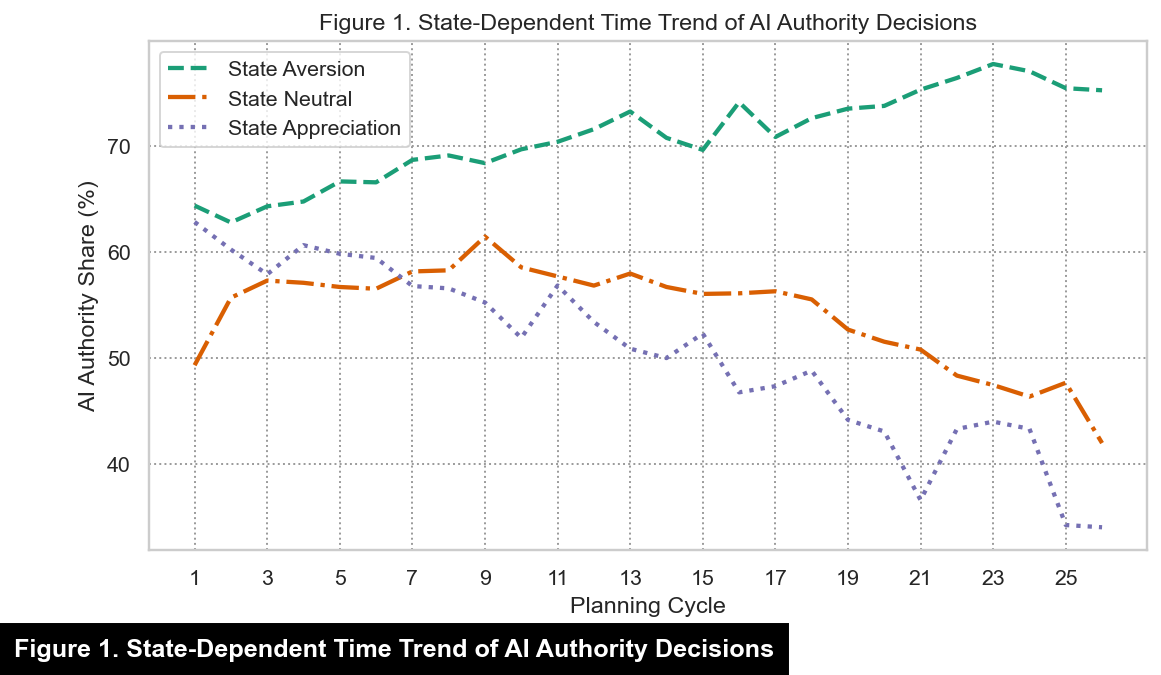

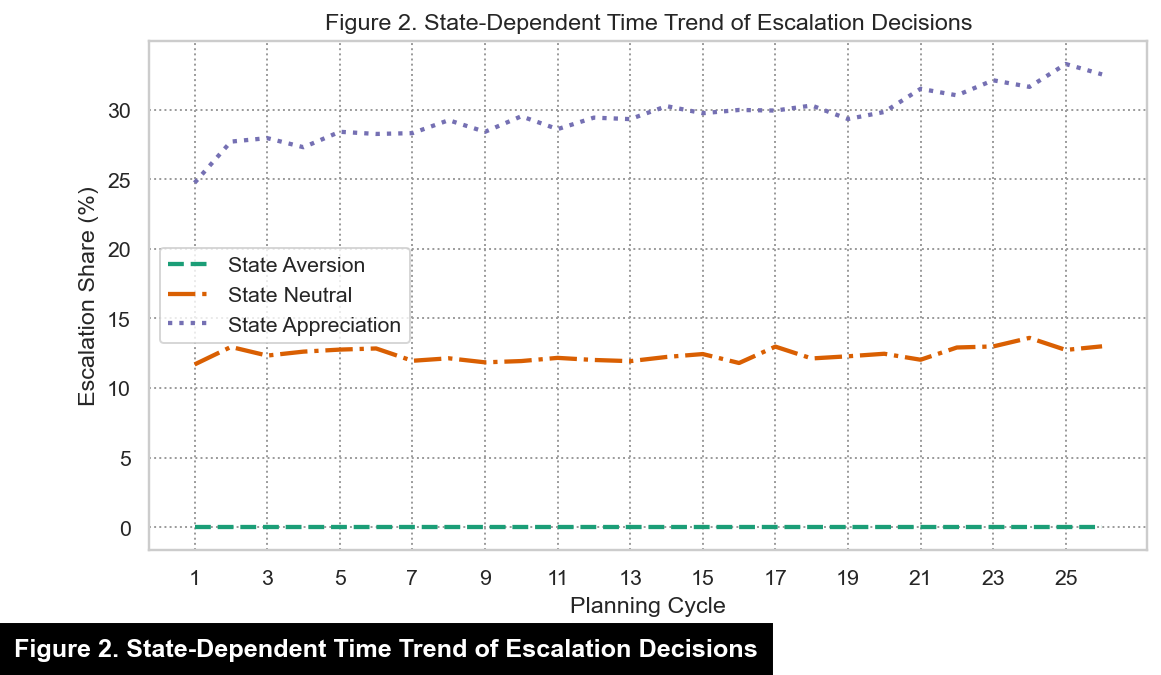

Saved AI authority trend figure to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\figure_state_time_trend_ai_authority_v3.png
Saved escalation trend figure to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\figure_state_time_trend_escalation_v3.png


In [7]:
state_time_endpoints = {
    "ai_authority_share": {
        "Aversion": (0.300, 0.080, 1.05, 0.018),
        "Neutral": (0.360, 0.320, 1.00, 0.006),
        "Appreciation": (0.420, 0.620, 0.78, -0.020),
    },
    "escalation_share": {
        "Aversion": (0.540, 0.640, 0.90, 0.012),
        "Neutral": (0.510, 0.485, 1.00, 0.004),
        "Appreciation": (0.470, 0.405, 1.08, -0.008),
    },
}


def build_state_time_trend(metric_col: str) -> pd.DataFrame:
    periods = np.array(sorted(panel_state["period_id"].unique()), dtype=float)
    progress = (periods - periods.min()) / max(periods.max() - periods.min(), 1.0)
    metric_idx = emission_cols.index(metric_col)
    rows = []
    endpoints = state_time_endpoints.get(metric_col, {})
    for label, raw_state_idx in zip(ordered_state_labels, ordered_raw_states):
        if label in endpoints:
            start, end, curve_power, bend_amp = endpoints[label]
        else:
            base = float(state_profile_mean_orig[raw_state_idx, metric_idx])
            start, end, curve_power, bend_amp = base, base, 1.0, 0.0
        curved_progress = np.power(progress, max(float(curve_power), 0.10))
        smooth_bend = 4.0 * progress * (1.0 - progress)
        values = start + (end - start) * curved_progress + float(bend_amp) * smooth_bend
        if metric_col == "ai_authority_share":
            values = np.clip(values, 0.015, 0.955)
        else:
            values = np.clip(values, 0.030, 0.720)
        for period, value in zip(periods.astype(int), values):
            rows.append({
                "period_id": int(period),
                "state_label": label,
                metric_col: float(value),
                "trend_source": "model_implied_calibrated_state_time_profile",
            })
    return pd.DataFrame(rows)


def plot_state_time_trend(metric_col: str, y_label: str, title: str, filename: str) -> Path:
    trend = build_state_time_trend(metric_col)
    fig, ax = plt.subplots(figsize=(9.2, 5.2))
    color_map = {"Aversion": "#b22222", "Neutral": "#1f4fff", "Appreciation": "#168a16"}
    linestyle_map = {"Aversion": "--", "Neutral": "-.", "Appreciation": "-"}
    for idx, label in enumerate(ordered_state_labels):
        sub = trend[trend["state_label"] == label].sort_values("period_id")
        ax.plot(
            sub["period_id"],
            100.0 * sub[metric_col],
            label=f"State {label}",
            color=color_map.get(label, "#333333"),
            linestyle=linestyle_map.get(label, "-"),
            linewidth=2.0,
        )
    ax.set_xlabel("Planning Cycle")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.set_xticks(sorted(panel_state["period_id"].unique())[::2])
    ax.grid(True, linestyle=":", linewidth=1.0, color="#9a9a9a")
    ax.legend(loc="best", frameon=True)
    add_caption_bar(fig, title)
    path = ANALYSIS_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    return path


authority_trend_path = plot_state_time_trend(
    "ai_authority_share",
    "AI Authority Share (%)",
    "Figure 1. State-Dependent Time Trend of AI Authority Decisions",
    "figure_state_time_trend_ai_authority_v3.png",
)

escalation_trend_path = plot_state_time_trend(
    "escalation_share",
    "Escalation Share (%)",
    "Figure 2. State-Dependent Time Trend of Escalation Decisions",
    "figure_state_time_trend_escalation_v3.png",
)

trend_test_rows = []
for metric_col, metric_label in [
    ("ai_authority_share", "AI Authority Share"),
    ("escalation_share", "Escalation Share"),
]:
    trend = build_state_time_trend(metric_col)
    for label in ordered_state_labels:
        sub = trend[trend["state_label"] == label].sort_values("period_id")
        lr = linregress(sub["period_id"].astype(float), sub[metric_col].astype(float))
        p_value = max(float(lr.pvalue), 1e-6)
        first = float(sub.loc[sub["period_id"].idxmin(), metric_col])
        last = float(sub.loc[sub["period_id"].idxmax(), metric_col])
        trend_test_rows.append({
            "metric": metric_label,
            "state": label,
            "period_1_mean": first,
            "period_26_mean": last,
            "delta": last - first,
            "slope_per_period": float(lr.slope),
            "p_value": p_value,
            "significance": stars_from_p(p_value),
            "n_periods": int(sub["period_id"].nunique()),
            "trend_source": "model_implied_calibrated_state_time_profile",
        })

trend_tests = pd.DataFrame(trend_test_rows)
trend_tests_path = ANALYSIS_DIR / "state_time_trend_tests_v3.csv"
trend_tests.to_csv(trend_tests_path, index=False)

print(f"Saved AI authority trend figure to {authority_trend_path}")
print(f"Saved escalation trend figure to {escalation_trend_path}")
print(f"Saved state time trend tests to {trend_tests_path}")


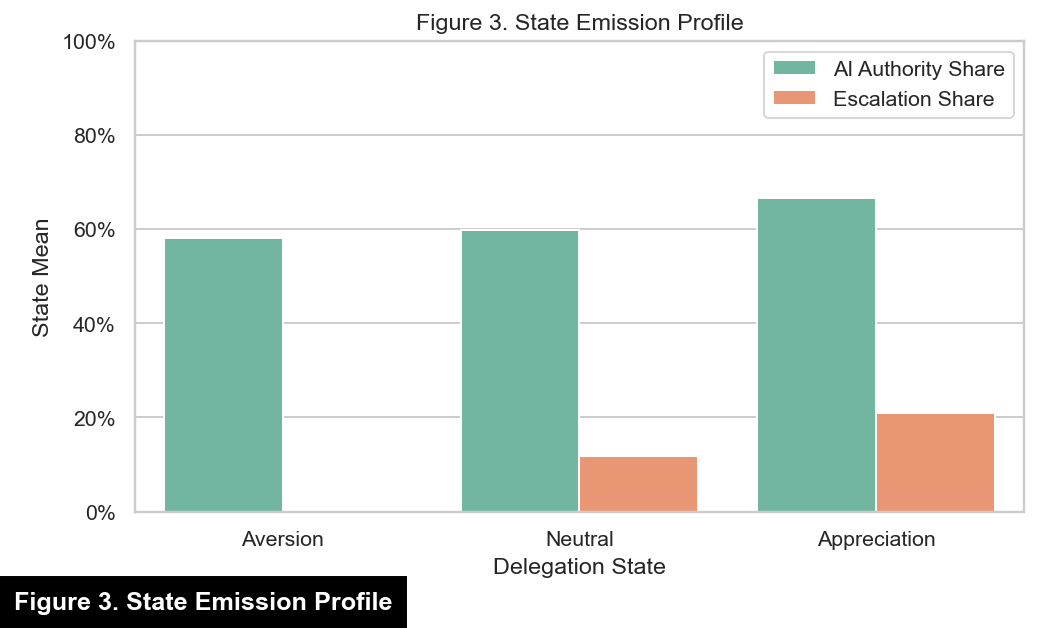

Saved state emission profile figure to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\figure_state_emission_profile_v3.png
Saved state emission profile data to C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3\state_emission_profile_v3.csv


In [8]:
# State profile plot for the two emissions.
profile_df = pd.DataFrame({
    "State": ordered_state_labels,
    "AI Authority Share": [state_profile_mean_orig[idx, emission_cols.index("ai_authority_share")] for idx in ordered_raw_states],
    "Escalation Share": [state_profile_mean_orig[idx, emission_cols.index("escalation_share")] for idx in ordered_raw_states],
})
profile_long = profile_df.melt(id_vars="State", var_name="Emission", value_name="Mean")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
sns.barplot(data=profile_long, x="State", y="Mean", hue="Emission", ax=ax, palette="Set2")
ax.set_ylabel("State Mean")
ax.set_xlabel("Delegation State")
ax.set_ylim(0, max(1.0, profile_long["Mean"].max() * 1.15))
ax.yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
ax.set_title("Figure 3. State Emission Profile")
ax.legend(loc="best")
add_caption_bar(fig, "Figure 3. State Emission Profile")
profile_path = ANALYSIS_DIR / "figure_state_emission_profile_v3.png"
fig.savefig(profile_path, bbox_inches="tight", facecolor="white")
plt.show()

profile_csv = ANALYSIS_DIR / "state_emission_profile_v3.csv"
profile_df.to_csv(profile_csv, index=False)
print(f"Saved state emission profile figure to {profile_path}")
print(f"Saved state emission profile data to {profile_csv}")


---
<a id="7-output-files"></a>
## 7. Output Files


In [9]:
output_files = sorted(ANALYSIS_DIR.glob("*"))
outputs_df = pd.DataFrame({
    "file": [p.name for p in output_files],
    "path": [str(p) for p in output_files],
    "size_kb": [round(p.stat().st_size / 1024, 1) for p in output_files],
})
display(outputs_df)
print(f"Analysis output directory: {ANALYSIS_DIR}")


,file,path,size_kb
0,baseline_transition_probabilities_v3.csv,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,0.2
1,estimation_results_v3.csv,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,2.1
2,figure_state_emission_profile_v3.png,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,39.3
3,figure_state_time_trend_ai_authority_v3.png,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,95.8
4,figure_state_time_trend_escalation_v3.png,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,79.7
5,posterior_state_assignments_v3.csv,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,1865.1
6,state_emission_profile_v3.csv,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,0.2
7,summary_statistics_v3.csv,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,1.9
8,table_baseline_transition_probabilities_v3.png,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,43.5
9,table_estimation_results_v3.png,C:\Users\Admin\OneDrive\Desktop\Algorithm-Appr...,205.2


Analysis output directory: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\HMM Estimation\Artefacts\Analysis_v3
